# Exploratory Data Analysis (EDA)

In [1]:
# import pandas & other libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# read the cap_app_inventory.csv in data folder into a dataframe called df
df = pd.read_csv('../data/cap_app_inventory.csv')
# display the first 5 rows of the dataframe
df.head()

,App_ID,App_Name,Department,Primary_Stakeholder,Hosting_Type
0,APP-001,Payroll Portal,HR,Sarah Jenkins,On-Premise
1,APP-002,Customer CRM,Sales,Michael Chen,Cloud-AWS
2,APP-003,Inventory Sync,Logistics,Sarah Jenkins,Cloud-Azure
3,APP-004,Global VPN,IT Security,David Miller,Hybrid
4,APP-005,Legacy Ledger,Finance,Robert Wilson,On-Premise


In [4]:
df_compliance = pd.read_csv('../data/cap_compliance_status.csv')
df_compliance.head()

,App_ID,Audit_Date,Compliance_Score,Status,Last_Reviewer
0,APP-001,2026-03-15,95%,Compliant,Audit_Team_A
1,APP-002,2026-04-01,60%,Non-Compliant,Audit_Team_B
2,APP-003,2026-03-20,85%,Compliant,Audit_Team_A
3,APP-004,2026-04-05,45%,Non-Compliant,Audit_Team_C
4,APP-005,2026-02-28,70%,Under Review,Audit_Team_B


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   App_ID               5 non-null      object
 1   App_Name             5 non-null      object
 2   Department           5 non-null      object
 3   Primary_Stakeholder  5 non-null      object
 4   Hosting_Type         5 non-null      object
dtypes: object(5)
memory usage: 332.0+ bytes


In [5]:
# Example of missing values & duplicates & wrong data types
data = {
    'Name': ['Alice', 'Bob', 'Charlie', None, 'Eve', 'Alice'],
    'Age': [25, 30, 35, "40", 45, 25],
    'City': [None, 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'New York']
}

In [6]:
df_data = pd.DataFrame(data)
df_data.head()

,Name,Age,City
0,Alice,25,None
1,Bob,30,Los Angeles
2,Charlie,35,Chicago
3,None,40,Houston
4,Eve,45,Phoenix


In [7]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    5 non-null      object
 1   Age     6 non-null      object
 2   City    5 non-null      object
dtypes: object(3)
memory usage: 276.0+ bytes


In [8]:
df_data.isna().sum()

Name    1
Age     0
City    1
dtype: int64

In [9]:
df_data1 = df_data.fillna('Unknown')
df_data1.head()

,Name,Age,City
0,Alice,25,Unknown
1,Bob,30,Los Angeles
2,Charlie,35,Chicago
3,Unknown,40,Houston
4,Eve,45,Phoenix


In [10]:
# convert Age column to numeric, coerce errors to NaN
df_data1['Age'] = pd.to_numeric(df_data1['Age'], errors='coerce')
df_data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    6 non-null      object
 1   Age     6 non-null      int64 
 2   City    6 non-null      object
dtypes: int64(1), object(2)
memory usage: 276.0+ bytes


In [11]:
# write to csv
df_data1.to_csv('../data/cleaned_data.csv', index=False)

# Basic Analysis

In [13]:
# in df_compliance, check the value counts of the 'Compliance Status' column
df_compliance['Status'].value_counts()

Status
Compliant        2
Non-Compliant    2
Under Review     1
Name: count, dtype: int64

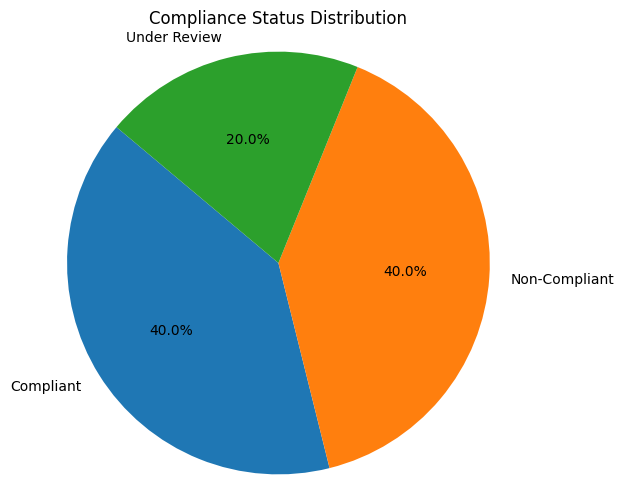

In [14]:
# generate pie chart of compliance status
status_counts = df_compliance['Status'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Compliance Status Distribution')
plt.axis('equal')
plt.show()